In [31]:
import pandas as pd
import glob

# Localizando todos os CSVs
caminhos = glob.glob("*.csv")
lista_dfs = []

print("--- Iniciando Carregamento ---")
for f in caminhos:
    temp_df = pd.read_csv(f)
    
    # CORREÇÃO: Padronização de colunas usando .str.lower()
    temp_df.columns = temp_df.columns.str.strip().str.lower()
    
    # Adicionando rastro de auditoria
    temp_df['origem_arquivo'] = f
    
    lista_dfs.append(temp_df)
    print(f"Arquivo carregado: {f} | Colunas: {len(temp_df.columns)}")

# Concatenando (Outer Join automático: colunas inexistentes viram NaN)
df = pd.concat(lista_dfs, ignore_index=True)

# CORREÇÃO DO TIMESTAMP (Formato Misto)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')

# Liberando memória no Lenovo i3
del lista_dfs
print("--- Unificação concluída com sucesso ---")

--- Iniciando Carregamento ---
Arquivo carregado: ambiente.csv | Colunas: 11
Arquivo carregado: banana.csv | Colunas: 11
Arquivo carregado: banana_terra.csv | Colunas: 11
Arquivo carregado: pablo_ambiente.csv | Colunas: 7
Arquivo carregado: pablo_banana.csv | Colunas: 7
Arquivo carregado: tomate.csv | Colunas: 11
--- Unificação concluída com sucesso ---


# Dados ausentes


In [36]:
# Analisar a situação real
print(df.isnull().sum())

# ESTRATÉGIA:
# Para sensores: Imputar mediana para não enviesar com zeros.
df['temperatura'] = df['temperatura'].fillna(df['temperatura'].median())
df['umidade_ar'] = df['umidade_ar'].fillna(df['umidade_ar'].median())
df['mq3_raw'] = df['mq3_raw'].fillna(df['mq3_raw'].median())

# Para o Target (Validade):
# Como você vai treinar uma IA, não podemos "inventar" a validade onde ela não existe.
# Mantemos apenas as linhas que têm rótulo (label).
df = df.dropna(subset=['validade'])
print(f"Dataset filtrado para treino: {len(df)} linhas.")

timestamp          0
tipofruta          0
lote               0
temperatura        0
umidade_ar         0
mq3_raw            0
mq3_tensao         0
estado_previsto    0
estado_real        0
validade           0
dtype: int64
Dataset filtrado para treino: 412 linhas.


# Limpeza de dados

In [37]:
# Substituir valores ausentes remanescentes em colunas categóricas
df['lote'] = df['lote'].fillna('desconhecido')

# Remover mq3_tensao: Já provamos que é redundante ao mq3_raw (Colinearidade)
if 'mq3_tensao' in df.columns:
    df = df.drop(columns=['mq3_tensao'])

# Limpeza de strings (remover espaços extras que podem vir do Arduino)
df['tipofruta'] = df['tipofruta'].str.strip()

# Exploração de dados

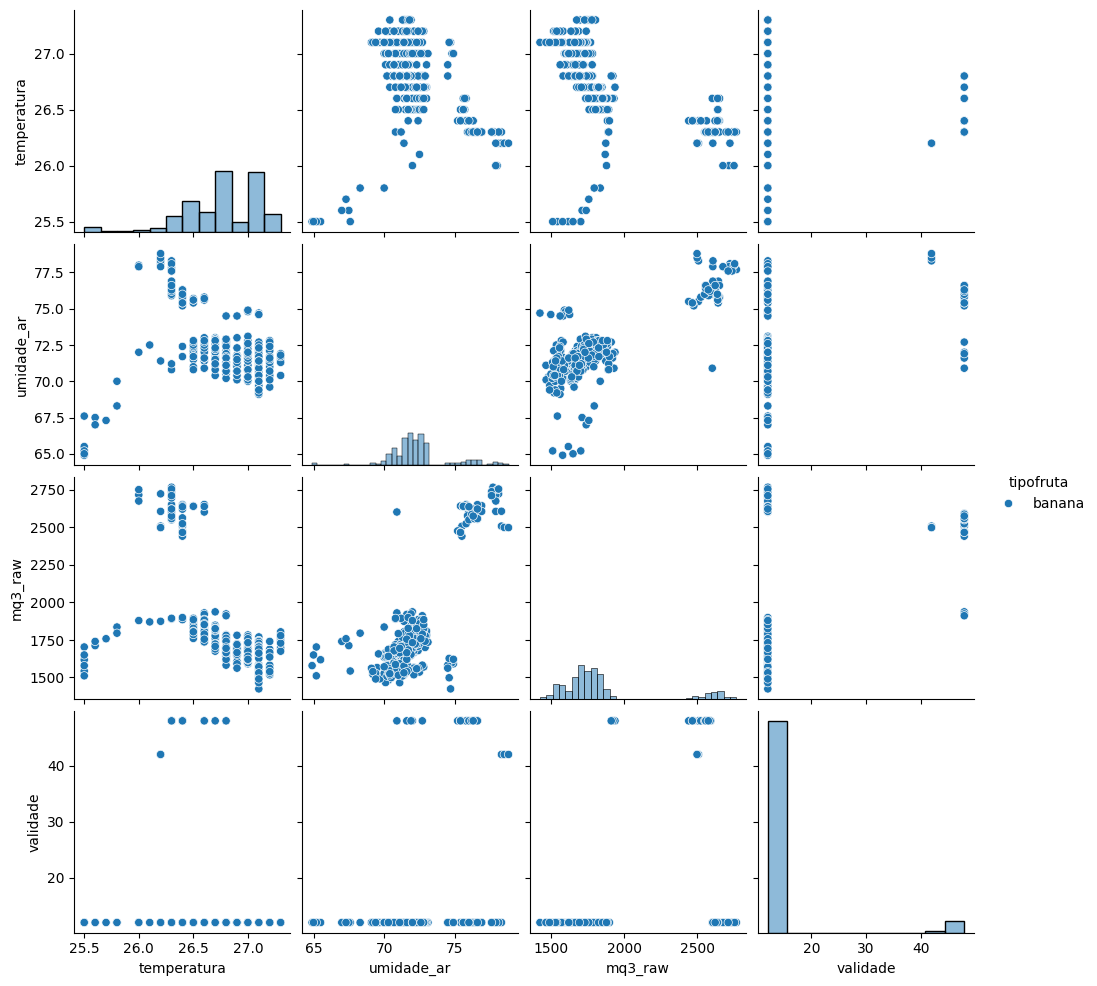

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# 3.1. Matriz de Pares (Foco em diferenciar tipos de fruta)
# Usamos sample para não travar o Lenovo i3
sns.pairplot(df.sample(min(len(df), 500)), hue='tipofruta', diag_kind='hist')
plt.show()

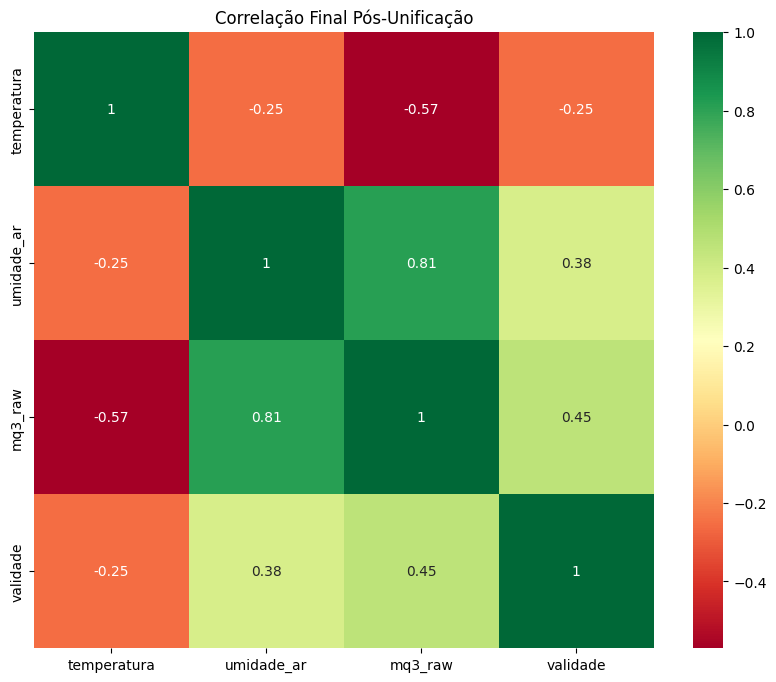

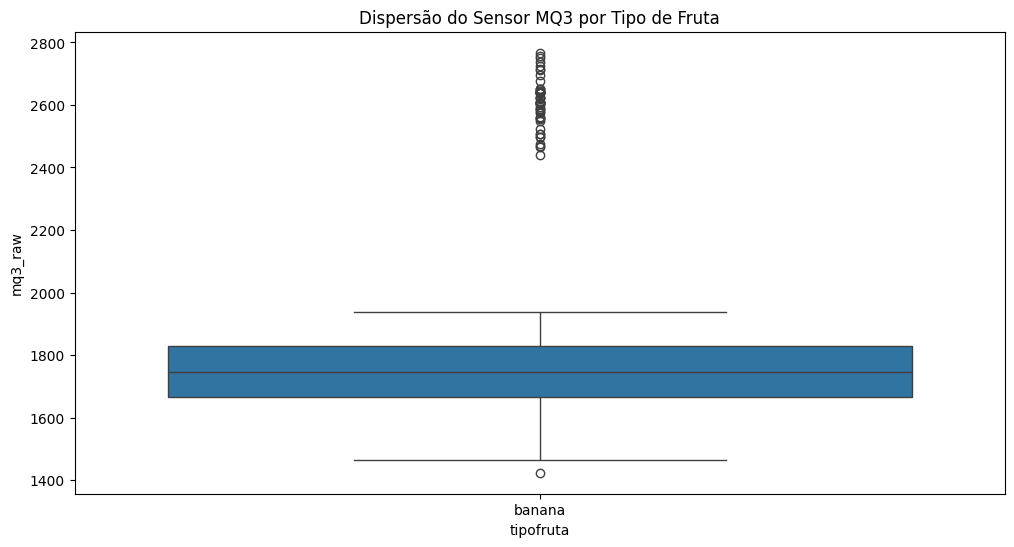

In [39]:
# 3.2. Matriz de Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn')
plt.title("Correlação Final Pós-Unificação")
plt.show()

# 3.3. Boxplot (Verificando Outliers entre frutas)
plt.figure(figsize=(12, 6))
sns.boxplot(x='tipofruta', y='mq3_raw', data=df)
plt.title("Dispersão do Sensor MQ3 por Tipo de Fruta")
plt.show()

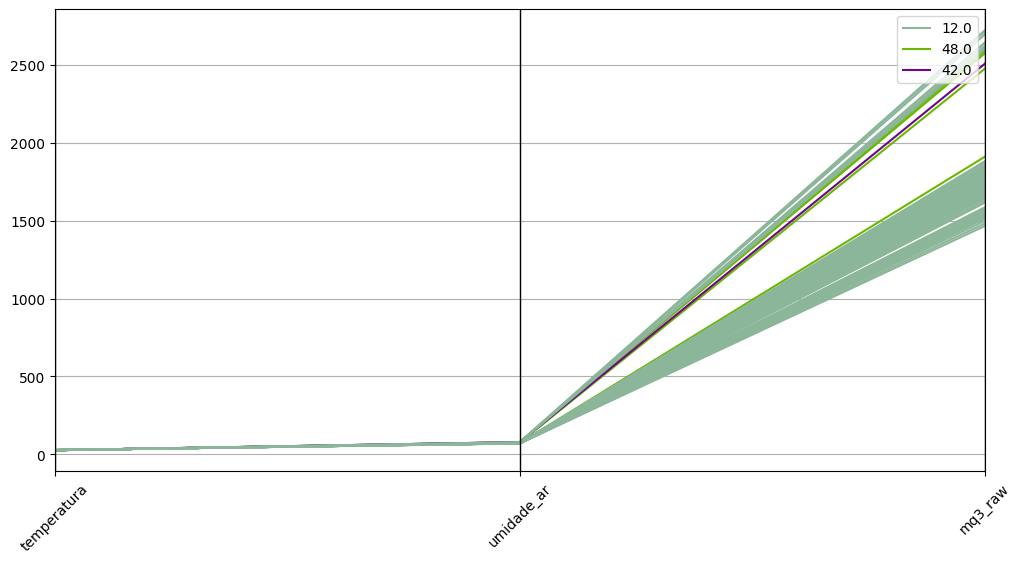

In [40]:
from pandas.plotting import parallel_coordinates
df_viz = df.sample(min(len(df), 100)).copy()
df_viz['validade_str'] = df_viz['validade'].astype(str)

plt.figure(figsize=(12, 6))
parallel_coordinates(df_viz[['temperatura', 'umidade_ar', 'mq3_raw', 'validade_str']], 'validade_str')
plt.xticks(rotation=45)
plt.show()

# Pré - processamento

In [43]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Converter timestamp com formato misto (conforme corrigido anteriormente)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')

# 2. Extrair atributos numéricos
df_proc = df.copy()
df_proc['hora'] = df['timestamp'].dt.hour
df_proc['dia_semana'] = df['timestamp'].dt.dayofweek

# Remove o timestamp original
df_proc = df_proc.drop(columns=['timestamp'], errors='ignore')

In [44]:
# A. Codifica Rótulo (Label Encoder) para tipofruta
le = LabelEncoder()
if 'tipofruta' in df_proc.columns:
    df_proc['tipofruta_n'] = le.fit_transform(df_proc['tipofruta'].astype(str))

# B. Variáveis Dummy para Lote
if 'lote' in df_proc.columns:
    df_proc = pd.get_dummies(df_proc, columns=['lote'], prefix='lote', drop_first=True)

# C. LIMPEZA FINAL: Removendo colunas de texto/metadados
# O segredo é o errors='ignore' para evitar o KeyError que você recebeu
colunas_para_remover = ['tipofruta', 'estado_previsto', 'estado_real', 'origem_arquivo', 'mq3_tensao']
df_proc = df_proc.drop(columns=colunas_para_remover, errors='ignore')

print("Limpeza concluída. Colunas atuais:", df_proc.columns.tolist())

Limpeza concluída. Colunas atuais: ['temperatura', 'umidade_ar', 'mq3_raw', 'validade', 'hora', 'dia_semana', 'tipofruta_n', 'lote_lote_Madrugada', 'lote_lote_Madrugada_2']


In [45]:
# Escalonamento para preparar para a RTX 3050 (Passo 5 e 6)
scaler = StandardScaler()
cols_sensores = ['temperatura', 'umidade_ar', 'mq3_raw']

# Certifica que as colunas existem antes de escalar
cols_presentes = [c for c in cols_sensores if c in df_proc.columns]
df_proc[cols_presentes] = scaler.fit_transform(df_proc[cols_presentes])

print("Check de Pré-processamento: OK")

Check de Pré-processamento: OK


# Seleção de atributos - colunas

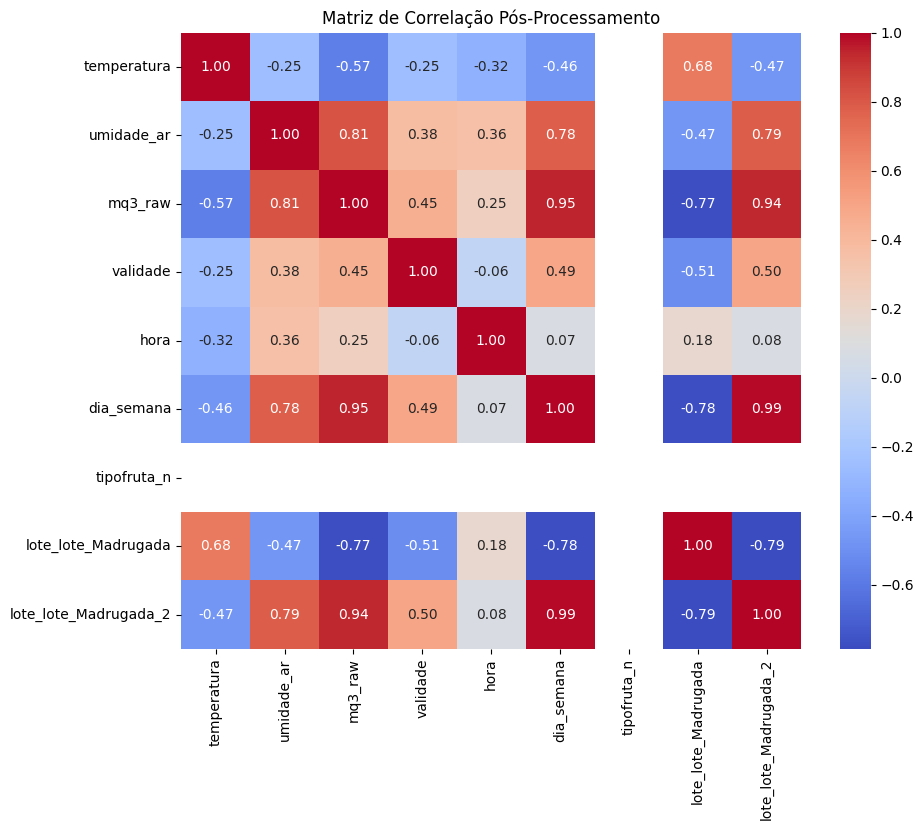

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df_proc.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação Pós-Processamento")
plt.show()

In [47]:
from sklearn.feature_selection import mutual_info_regression

# Definindo X (features) e y (target)
X = df_proc.drop(columns=['validade'])
y = df_proc['validade']

mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print("--- Ranking de Importância (Mutual Information) ---")
print(mi_series)

--- Ranking de Importância (Mutual Information) ---
mq3_raw                  0.222074
dia_semana               0.147158
lote_lote_Madrugada_2    0.135519
lote_lote_Madrugada      0.109070
umidade_ar               0.086428
hora                     0.072649
tipofruta_n              0.040800
temperatura              0.010717
dtype: float64


In [48]:
from sklearn.linear_model import LassoCV

# O LassoCV encontra o melhor parâmetro de penalidade sozinho
lasso = LassoCV(cv=5).fit(X, y)
atributos_mantidos = X.columns[lasso.coef_ != 0].tolist()

print(f"Atributos selecionados pelo LASSO: {atributos_mantidos}")

Atributos selecionados pelo LASSO: ['umidade_ar', 'mq3_raw', 'hora', 'lote_lote_Madrugada']


In [49]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Configurado com poucos estimadores para respeitar o hardware do i3
selector = RFE(RandomForestRegressor(n_estimators=10, random_state=42), n_features_to_select=5)
selector = selector.fit(X, y)

ranking = pd.Series(selector.ranking_, index=X.columns).sort_values()
print("--- Ranking RFE (1 é o melhor) ---")
print(ranking)

--- Ranking RFE (1 é o melhor) ---
temperatura              1
umidade_ar               1
mq3_raw                  1
hora                     1
dia_semana               1
lote_lote_Madrugada      2
tipofruta_n              3
lote_lote_Madrugada_2    4
dtype: int64


# Classes desbalanceadas

In [52]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# X e y já definidos no passo anterior
X_final = df_proc.drop(columns=['validade'])
y_final = df_proc['validade']

# SOLUÇÃO: k_neighbors deve ser menor que o número de amostras da menor classe (3 - 1 = 2)
over = SMOTE(sampling_strategy='auto', k_neighbors=2, random_state=42)
under = RandomUnderSampler(sampling_strategy='auto', random_state=42)

pipeline = Pipeline(steps=[('o', over), ('u', under)])

try:
    X_resampled, y_resampled = pipeline.fit_resample(X_final, y_final)
    print("--- Nova Distribuição Pós-SMOTE ---")
    print(pd.Series(y_resampled).value_counts())
except Exception as e:
    print(f"Erro persistente: {e}")

--- Nova Distribuição Pós-SMOTE ---
validade
12.0    387
42.0    387
48.0    387
Name: count, dtype: int64


In [53]:
# OPCIONAL: Se quiser simplificar o problema
df_proc['validade_binaria'] = df_proc['validade'].apply(lambda x: 1 if x == 48.0 else 0)
print("Distribuição Binária:\n", df_proc['validade_binaria'].value_counts())

Distribuição Binária:
 validade_binaria
0    390
1     22
Name: count, dtype: int64


# Treinamento e Avaliação

In [54]:
from sklearn.model_selection import train_test_split

# Usando o dataset balanceado pelo SMOTE
X = X_resampled
y = y_resampled

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 928 amostras | Teste: 233 amostras


In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Criando e treinando o modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Fazendo previsões
y_pred = modelo.predict(X_test)

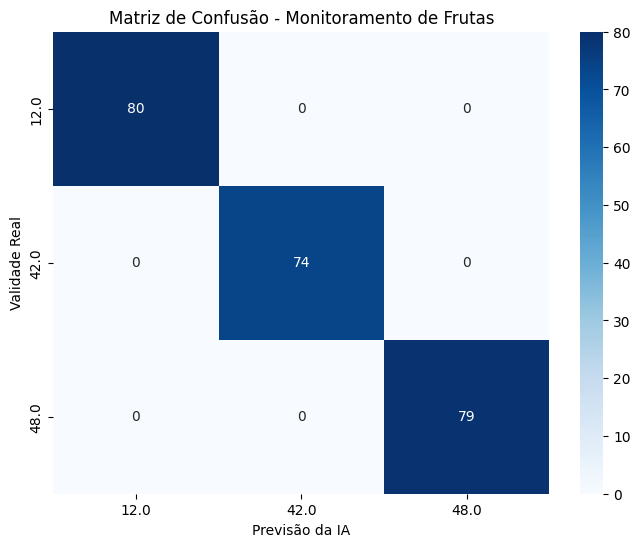


Relatório de Classificação:
              precision    recall  f1-score   support

        12.0       1.00      1.00      1.00        80
        42.0       1.00      1.00      1.00        74
        48.0       1.00      1.00      1.00        79

    accuracy                           1.00       233
   macro avg       1.00      1.00      1.00       233
weighted avg       1.00      1.00      1.00       233



In [60]:
import seaborn as sns

# Matriz de Confusão: Mostra onde o modelo está errando
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.xlabel('Previsão da IA')
plt.ylabel('Validade Real')
plt.title('Matriz de Confusão - Monitoramento de Frutas')
plt.show()

# Relatório Completo (Precision, Recall, F1-Score)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Deployment

In [61]:
import joblib

# Salvando o modelo, o escalonador e o encoder de labels
artefatos = {
    'modelo': modelo,
    'scaler': scaler,
    'label_encoder': le,
    'features': X.columns.tolist()
}

joblib.dump(artefatos, 'modelo_monitoramento_frutas.pkl')
print("Modelo e artefatos salvos com sucesso!")

Modelo e artefatos salvos com sucesso!


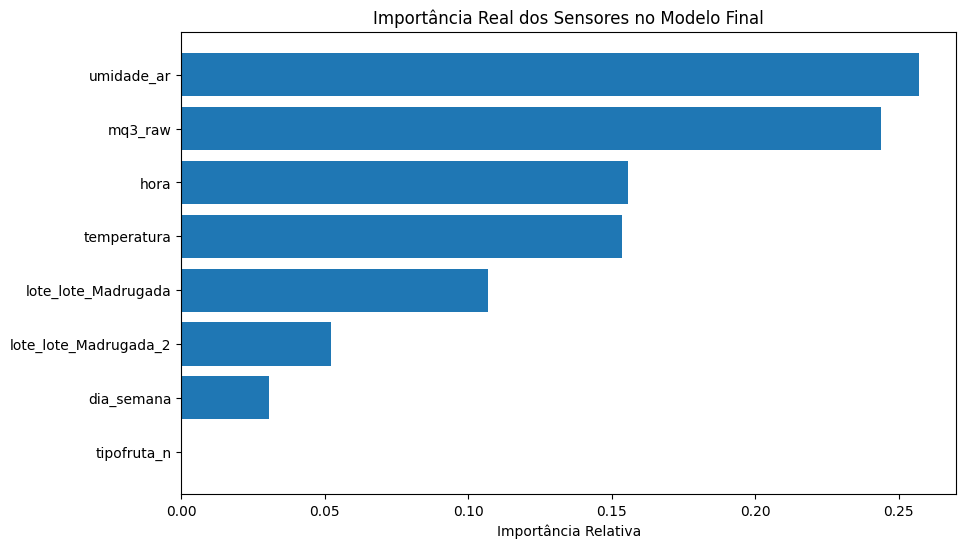

In [62]:
import numpy as np

importances = modelo.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Importância Real dos Sensores no Modelo Final')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importância Relativa')
plt.show()